## 1. Descriptive Statistics Analysis - Wine Quality Dataset

1. Tổng quan về cấu trúc bộ dữ liệu (Multivariate).
2. Tính toán các đại lượng thống kê: Mean, Variance cho Quần thể và Mẫu.
3. Phân tích hệ số tương quan giữa các biến.

In [ ]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath(".."))  
from source.utils import mean, variance, standard_deviation, covariance, correlation

sns.set_style("whitegrid")

try:
    df = pandas.read_csv("../data/WineQT.csv")
    print("Tải dữ liệu thành công.")
except FileNotFoundError:
    print("Không tìm thấy file dữ liệu. Vui lòng kiểm tra lại đường dẫn.")

print(df.head())

Tải dữ liệu thành công.
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8

## Tổng quan dữ liệu

In [2]:
print(f"Số lượng sample: {df.shape[0]}")
print(f"Số lượng cột (biến): {df.shape[1]}")
print("-" * 30)
df.info()

Số lượng sample: 1143
Số lượng cột (biến): 13
------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


## Mean và Variance

In [7]:
import pandas as pd

# Population
pop_mean = {col: mean(df[col]) for col in df.columns}
pop_var = {col: variance(df[col]) for col in df.columns}

# Lấy mẫu ngẫu nhiên 
sample_n = 100
df_sample = df.sample(n=sample_n, random_state=42)

# 3. Mean and Variance of the Sample
sample_mean = {col: mean(df_sample[col]) for col in df_sample.columns}
sample_var = {col: variance(df_sample[col]) for col in df_sample.columns}

# Tạo bảng so sánh cho một biến cụ thể
comparison = pd.DataFrame({
    'Metric': ['Mean', 'Variance'],
    'Population': [pop_mean['alcohol'], pop_var['alcohol']],
    'Sample (n=100)': [sample_mean['alcohol'], sample_var['alcohol']]
})

print("So sánh biến 'alcohol' giữa Population và Sample:")
print(comparison)

So sánh biến 'alcohol' giữa Population và Sample:
     Metric  Population  Sample (n=100)
0      Mean   10.442111       10.507333
1  Variance    1.171147        1.240395


## Phân tích tương quan

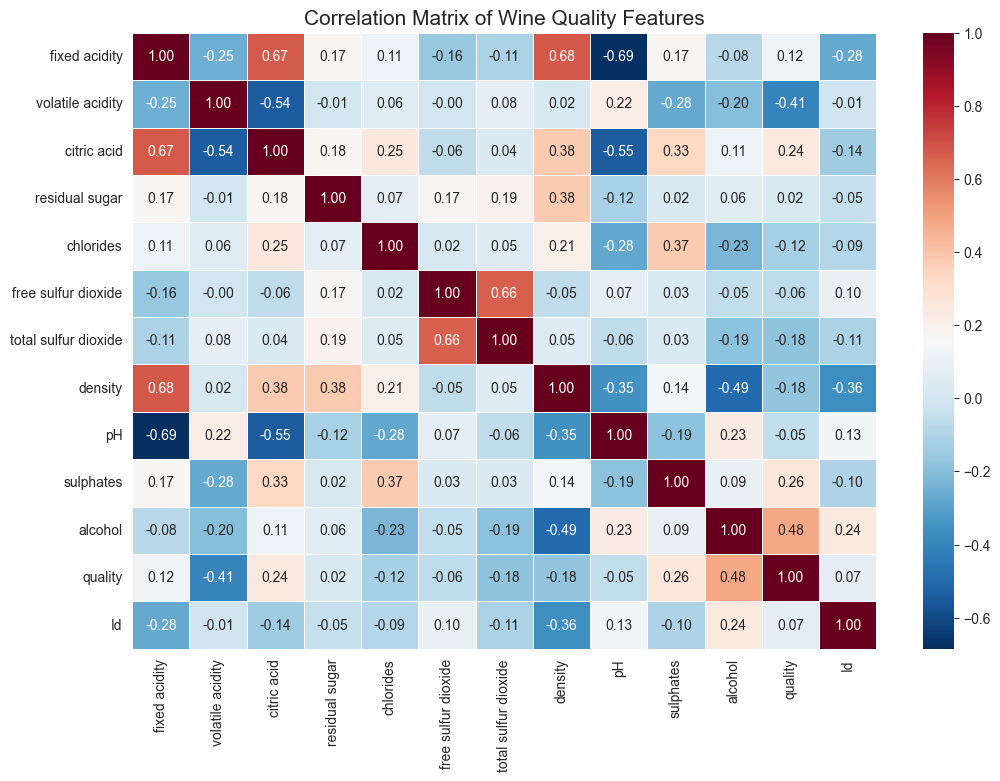

Tương quan của các biến với Quality (giảm dần):
quality                 1.000000
alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
Id                      0.069708
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64


In [4]:
# Correlation Matrix
corr_matrix = df.corr()

# Vẽ Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Wine Quality Features', fontsize=15)
plt.show()

# Trích xuất các biến có tương quan mạnh nhất với Quality
print("Tương quan của các biến với Quality (giảm dần):")
print(corr_matrix['quality'].sort_values(ascending=False))

## Visualization


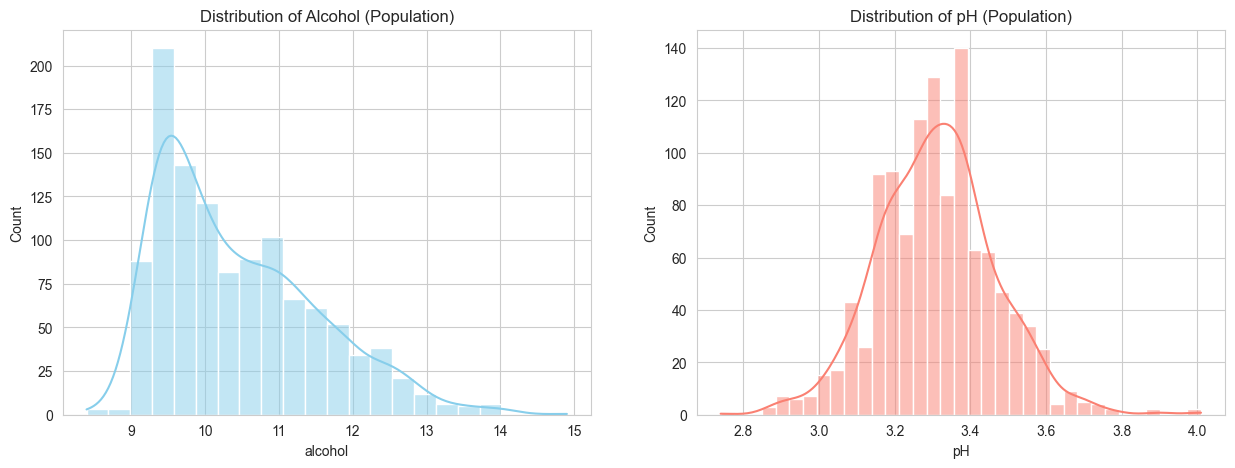

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Phân phối của Alcohol
sns.histplot(df['alcohol'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Alcohol (Population)')

# Phân phối của pH
sns.histplot(df['pH'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of pH (Population)')

plt.show()